In [2]:
import sys, os
from pathlib import Path

PROJECT      = "/kaggle/working"
L2A_SRC      = "/kaggle/input/datasets/surathbob/hiwaf-l2a-v1"
L2B_SRC      = "/kaggle/input/datasets/surathbob/hiwaf-l2b-v1"
SPLIT_SRC    = "/kaggle/input/datasets/surathbob/hiwaf-split-v1"

sys.path.insert(0, PROJECT)
sys.path.insert(0, SPLIT_SRC)   # feature_engineering/
os.chdir(PROJECT)
Path("results").mkdir(exist_ok=True)

print(f"Working dir: {os.getcwd()}")

Working dir: /kaggle/working


In [3]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import time, re, json
import scipy.special
from pathlib import Path
from sklearn.metrics import confusion_matrix

from feature_engineering.extractor import extract_features, to_vector, FEATURE_NAMES, strip_to_path_query
from feature_engineering.tokenizer import CharTokenizer
from feature_engineering.normalizer import Normalizer

CLASS_NAMES = ["normal", "sqli", "xss", "lfi", "other_attack"]

# ── L2A ──────────────────────────────────────────────────────────────────
l2a_metadata = json.load(open(f"{L2A_SRC}/exported_models/layer2a_metadata.json"))
l2a_winner   = l2a_metadata["winner"]
l2a_onnx_name = ("layer2a_shallow_autoencoder.onnx" if l2a_winner == "Shallow Autoencoder"
                  else "layer2a_isolation_forest.onnx")
l2a_sess = ort.InferenceSession(f"{L2A_SRC}/exported_models/{l2a_onnx_name}")
norm     = Normalizer.load(f"{SPLIT_SRC}/exported_models/scaler_l2a.pkl")

l2a_key = "shallow_autoencoder" if l2a_winner == "Shallow Autoencoder" else "isolation_forest"
L2A_THRESHOLD = l2a_metadata[l2a_key]["threshold"]
l2a_input_name = l2a_sess.get_inputs()[0].name

# ── L2B ──────────────────────────────────────────────────────────────────
l2b_metadata = json.load(open(f"{L2B_SRC}/exported_models/layer2b_metadata.json"))
l2b_sess = ort.InferenceSession(f"{L2B_SRC}/exported_models/layer2b_bigru.onnx")
tok      = CharTokenizer(max_len=512)

print(f"✅ L2A: {l2a_winner:<25} input='{l2a_input_name}'  threshold={L2A_THRESHOLD:.6f}")
print(f"✅ L2B: {l2b_metadata['headline_model']} (fixed headline)  sweep_point='{l2b_metadata['selected_sweep_point']}'")

[Normalizer] Loaded from /kaggle/input/datasets/surathbob/hiwaf-split-v1/exported_models/scaler_l2a.pkl
✅ L2A: Shallow Autoencoder       input='input'  threshold=0.002985
✅ L2B: BiGRU (fixed headline)  sweep_point='8k'


In [5]:
# CHANGED: L1 rules reuse the SAME regexes extract_features() uses
# internally, rather than a hand-copied, drifted duplicate. Import the
# compiled patterns directly instead of re-writing them.
from feature_engineering.extractor import _SQLI, _XSS, _LFI, _OSCI

def layer1_check(url: str, body: str) -> tuple:
    """
    Returns (blocked: bool, reason: str). Regex-only — rate limiting is
    excluded here since it requires sequential request history and isn't
    meaningful for i.i.d. single-request test-set evaluation. Noted
    explicitly rather than silently omitted.
    """
    txt = url + " " + body
    if _SQLI.search(txt): return True, "sqli_rule"
    if _XSS.search(txt):  return True, "xss_rule"
    if _LFI.search(txt):  return True, "lfi_rule"
    if _OSCI.search(txt): return True, "other_attack_rule"   # CHANGED: was "cmdi_rule"
    return False, ""

print("✅ Layer 1 rules loaded (shared regex source with extract_features())")
tests = [
    ("/?id=1 UNION SELECT * FROM users", "", True),
    ("<script>alert(1)</script>",          "", True),
    ("/../../../etc/passwd",               "", True),
    ("/api/products?cat=shoes",            "", False),
]
print("  Smoke tests:")
for url, body, expected in tests:
    result, reason = layer1_check(url, body)
    status = "✅" if result == expected else "❌"
    print(f"    {status} {url[:40]:<40} blocked={result}")

✅ Layer 1 rules loaded (shared regex source with extract_features())
  Smoke tests:
    ✅ /?id=1 UNION SELECT * FROM users         blocked=True
    ✅ <script>alert(1)</script>                blocked=True
    ✅ /../../../etc/passwd                     blocked=True
    ✅ /api/products?cat=shoes                  blocked=False


In [6]:
# CHANGED: threat-score coefficients are now named constants, not magic
# numbers buried in the function — makes the Priority C sensitivity sweep
# (R2 Issue 6: 30/70 boundaries, x15/x50 coefficients) a config change,
# not a code edit.
L2A_SCORE_MULTIPLIER = 15.0   # l2a_contrib = min(50, l2a_score * L2A_SCORE_MULTIPLIER)
L2B_CONF_MULTIPLIER  = 50.0   # l2b_contrib = pred_conf * L2B_CONF_MULTIPLIER (0 if predicted normal)
LOG_THRESHOLD   = 30
BLOCK_THRESHOLD = 70

def run_pipeline(
    request: dict,
    l2a_threshold=L2A_THRESHOLD,
    l2a_mult=L2A_SCORE_MULTIPLIER,
    l2b_mult=L2B_CONF_MULTIPLIER,
    log_thr=LOG_THRESHOLD,
    block_thr=BLOCK_THRESHOLD,
) -> dict:
    """Full WAF pipeline: L1 -> L2A -> L2B -> Threat Score. Threat score
    formula fixed per accepted paper: s = min(100, c_L2A + c_L2B)."""
    url  = str(request.get("url",  ""))
    body = str(request.get("body", ""))
    t0   = time.perf_counter()

    l1_blocked, l1_reason = layer1_check(url, body)
    if l1_blocked:
        return {
            "layer": "L1",
            "decision": "block",
            "score": 100,
            "label": l1_reason,
            "latency_ms": round((time.perf_counter() - t0) * 1000, 3),
    
            # ML layers were never executed
            "l2a_score": None,
            "l2a_contrib": None,
            "l2b_contrib": None,
        }

    features = extract_features(request)
    fvec     = norm.transform(to_vector(features)).astype(np.float32)

    if l2a_winner == "Shallow Autoencoder":
        recon     = l2a_sess.run(None, {l2a_input_name: fvec})[0]
        l2a_score = float(np.mean((fvec - recon) ** 2))
    else:
        l2a_score = float(-l2a_sess.run(None, {l2a_input_name: fvec})[0][0])

    if l2a_score < l2a_threshold:
        return {
            "layer": "L2A", "decision": "allow", "score": 0, "label": "normal",
            "latency_ms": round((time.perf_counter() - t0) * 1000, 3),
            "l2a_score": round(l2a_score, 6),
            "l2a_contrib": 0.0, "l2b_contrib": 0.0,
        }

    tokens = tok.encode_request(request).reshape(1, -1).astype(np.int64)
    logits = l2b_sess.run(None, {"token_ids": tokens})[0][0]

    proba      = scipy.special.softmax(logits)
    pred_cls   = int(np.argmax(proba))
    pred_conf  = float(proba[pred_cls])
    pred_label = CLASS_NAMES[pred_cls]

    l2a_contrib  = min(50.0, l2a_score * l2a_mult)
    l2b_contrib  = 0.0 if pred_cls == 0 else pred_conf * l2b_mult
    threat_score = min(100, int(l2a_contrib + l2b_contrib))

    if threat_score >= block_thr:  decision = "block"
    elif threat_score >= log_thr:  decision = "log"
    else:                          decision = "allow"

    return {
        "layer": "L2B", "decision": decision, "score": threat_score, "label": pred_label,
        "confidence": round(pred_conf, 4),
        "l2a_score": round(l2a_score, 6),
        "l2a_contrib": round(l2a_contrib, 2), "l2b_contrib": round(l2b_contrib, 2),
        "latency_ms": round((time.perf_counter() - t0) * 1000, 3),
    }

print("✅ Pipeline function ready")

✅ Pipeline function ready


In [7]:
from tqdm import tqdm

# CHANGED: uses l2b_test_raw.csv directly — the exact same 3,693 rows that
# produced l2b_test_X_numeric.npy/l2b_test_y.npy, verified aligned in
# Notebook 02's addendum. NOT a fresh re-split (the old notebook's bug).
test_df = pd.read_csv(f"{SPLIT_SRC}/data/splits/l2b_test_raw.csv")
print(f"Test set: {len(test_df):,} requests (family-aware, verified-aligned)")
print(test_df["attack_class"].value_counts())

results_list = []
errors = 0
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Running WAF pipeline"):
    req = {
        "url": str(row.get("url", "")), "method": str(row.get("method", "GET")),
        "headers": {}, "body": str(row.get("body", "")),
    }
    try:
        res = run_pipeline(req)
        res["true_label"]    = row["attack_class"]
        res["true_label_id"] = row["attack_class_id"]
        results_list.append(res)
    except Exception as e:
        errors += 1
        if errors <= 3:
            print(f"  Error: {e}")

df_results = pd.DataFrame(results_list)
if errors > 0:
    print(f"  ⚠️  {errors} requests errored and were skipped")

print(f"\n--- Pipeline decisions ---\n{df_results['decision'].value_counts().to_string()}")
print(f"\n--- Layer routing ---\n{df_results['layer'].value_counts().to_string()}")
print(f"\nMean latency: {df_results['latency_ms'].mean():.3f}ms")

Test set: 3,693 requests (family-aware, verified-aligned)
attack_class
sqli            1929
normal           603
lfi              447
other_attack     434
xss              280
Name: count, dtype: int64


Running WAF pipeline: 100%|██████████| 3693/3693 [00:10<00:00, 343.71it/s] 


--- Pipeline decisions ---
decision
block    2155
allow    1132
log       406

--- Layer routing ---
layer
L1     2118
L2A    1105
L2B     470

Mean latency: 2.771ms


In [8]:
# DECISION: "block" AND "log" both count as "detected" for TPR/FPR purposes
# — "log" is a real signal (score 30-69), not a miss. A normal request that
# gets logged is still a false positive; an attack that gets logged is
# still detected, just not blocked outright. Reported both ways below so
# the choice is visible, not hidden in one number.

y_true = (df_results["true_label_id"] > 0).astype(int)

for tier_name, positive_decisions in [
    ("block only",        {"block"}),
    ("block + log",       {"block", "log"}),
]:
    y_pred = df_results["decision"].isin(positive_decisions).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    acc  = (tp + tn) / len(y_true)

    print(f"=== END-TO-END RESULTS ({tier_name} = positive) ===")
    print(f"  Accuracy:  {acc:.4f}   Detection(TPR): {tpr:.4f}   FPR: {fpr:.4f}   Precision: {prec:.4f}")
    print(f"  TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}\n")

=== END-TO-END RESULTS (block only = positive) ===
  Accuracy:  0.7468   Detection(TPR): 0.6974   FPR: 0.0000   Precision: 1.0000
  TP=2,155  FP=0  TN=603  FN=935

=== END-TO-END RESULTS (block + log = positive) ===
  Accuracy:  0.8568   Detection(TPR): 0.8288   FPR: 0.0000   Precision: 1.0000
  TP=2,561  FP=0  TN=603  FN=529



=== Latency — full pipeline (ms) ===
  Mean: 2.771  Median: 0.021  P95: 19.789  P99: 25.348  Max: 29.522
  Target: P99 < 20ms — WARN ⚠️ (25.3ms)

  Latency by layer:
    L2A: mean=0.49ms  p99=1.20ms  n=1,105
    L2B: mean=20.57ms  p99=26.73ms  n=470
    L1: mean=0.01ms  p99=0.05ms  n=2,118


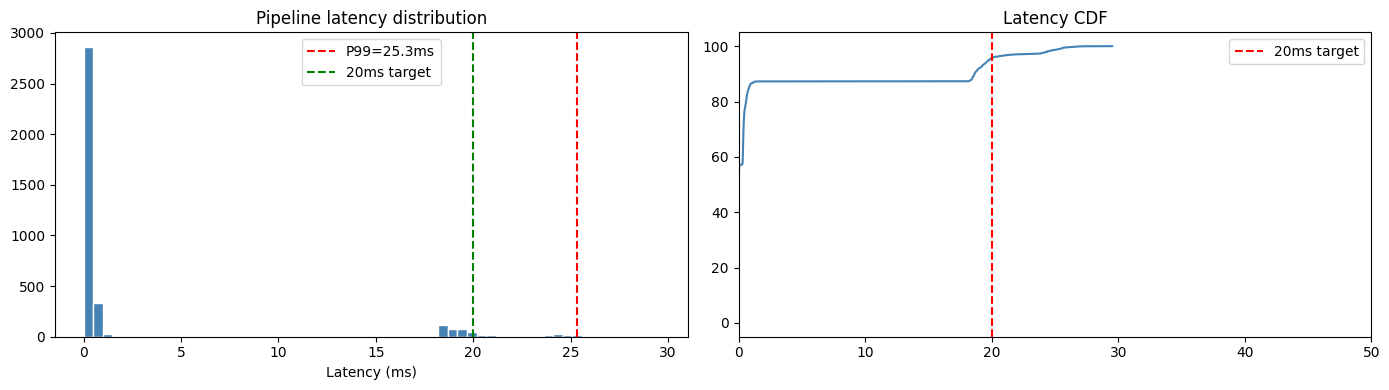

In [9]:
lat = df_results["latency_ms"]
print("=== Latency — full pipeline (ms) ===")
print(f"  Mean: {lat.mean():.3f}  Median: {lat.median():.3f}  P95: {lat.quantile(0.95):.3f}  P99: {lat.quantile(0.99):.3f}  Max: {lat.max():.3f}")
print(f"  Target: P99 < 20ms — {'PASS ✅' if lat.quantile(0.99) <= 20 else f'WARN ⚠️ ({lat.quantile(0.99):.1f}ms)'}")

print("\n  Latency by layer:")
for layer in df_results["layer"].unique():
    sub = df_results[df_results["layer"] == layer]["latency_ms"]
    print(f"    {layer}: mean={sub.mean():.2f}ms  p99={sub.quantile(0.99):.2f}ms  n={len(sub):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(lat.clip(0, 30), bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(lat.quantile(0.99), color="red", linestyle="--", label=f"P99={lat.quantile(0.99):.1f}ms")
axes[0].axvline(20, color="green", linestyle="--", label="20ms target")
axes[0].set_xlabel("Latency (ms)"); axes[0].set_title("Pipeline latency distribution"); axes[0].legend()

sorted_lat = np.sort(lat.values)
cdf = np.arange(1, len(sorted_lat)+1) / len(sorted_lat)
axes[1].plot(sorted_lat, cdf * 100, color="steelblue")
axes[1].axvline(20, color="red", linestyle="--", label="20ms target")
axes[1].set_xlim(0, 50); axes[1].set_title("Latency CDF"); axes[1].legend()

plt.tight_layout()
plt.savefig("results/06_latency.png", dpi=120)
plt.show()

In [10]:
print("=== Detection by attack class (block-only) ===")
for cls in ["sqli", "xss", "lfi", "other_attack"]:
    cls_df   = df_results[df_results["true_label"] == cls]
    detected = (cls_df["decision"] == "block").sum()
    total    = len(cls_df)
    rate     = detected / total * 100 if total > 0 else 0
    status   = "✅" if rate >= 90 else "⚠️ "
    print(f"  {status} {cls:<15}: {detected:>5}/{total:<5}  ({rate:.1f}%)")

normal_df = df_results[df_results["true_label"] == "normal"]
fp_cnt = (normal_df["decision"] == "block").sum()
print(f"\nFalse positives (normal blocked): {fp_cnt}/{len(normal_df)} ({fp_cnt/len(normal_df)*100:.2f}%)")

print("\n=== Layer routing breakdown ===")
total_reqs = len(df_results)
labels = {"L1": "known attacks caught by rules", "L2A": "allowed as normal (below threshold)", "L2B": "anomalous — scored by BiGRU"}
for layer in ["L1", "L2A", "L2B"]:
    n = (df_results["layer"] == layer).sum()
    print(f"  {layer}: {n:,} ({n/total_reqs*100:.1f}%) — {labels[layer]}")

=== Detection by attack class (block-only) ===
  ✅ sqli           :  1812/1929   (93.9%)
  ⚠️  xss            :   248/280    (88.6%)
  ⚠️  lfi            :    52/447    (11.6%)
  ⚠️  other_attack   :    43/434    (9.9%)

False positives (normal blocked): 0/603 (0.00%)

=== Layer routing breakdown ===
  L1: 2,118 (57.4%) — known attacks caught by rules
  L2A: 1,105 (29.9%) — allowed as normal (below threshold)
  L2B: 470 (12.7%) — anomalous — scored by BiGRU


In [11]:
# Resolves R2 Critical Issue 1: a genuine Allow/Log/Block x ground-truth
# matrix from ONE pipeline run, not L2A FPR mixed with L2B accuracy/F1.
decision_order = ["allow", "log", "block"]
truth_order    = ["normal"] + [c for c in CLASS_NAMES if c != "normal"]

cm_unified = pd.crosstab(df_results["true_label"], df_results["decision"]).reindex(
    index=truth_order, columns=decision_order, fill_value=0)
print("Unified Confusion Matrix (ground truth x decision)")
print(cm_unified)
cm_unified.to_csv("results/06_unified_confusion_matrix.csv")

Unified Confusion Matrix (ground truth x decision)
decision      allow  log  block
true_label                     
normal          603    0      0
sqli              1  116   1812
xss               3   29    248
lfi             362   33     52
other_attack    163  228     43


In [12]:
df_results.to_csv("results/06_pipeline_results.csv", index=False)

y_pred_block_only = (df_results["decision"] == "block").astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_block_only, labels=[0, 1]).ravel()

final_report = {
    "test_set_size": len(df_results),
    "l1_block_pct": float((df_results["layer"] == "L1").mean() * 100),
    "end_to_end_accuracy": float((tp + tn) / len(y_true)),
    "detection_rate_block_only": float(tp / (tp + fn)) if (tp + fn) > 0 else None,
    "fpr_block_only": float(fp / (fp + tn)) if (fp + tn) > 0 else None,
    "precision_block_only": float(tp / (tp + fp)) if (tp + fp) > 0 else None,
    "mean_latency_ms": float(df_results["latency_ms"].mean()),
    "p99_latency_ms": float(df_results["latency_ms"].quantile(0.99)),
    "threat_score_coefficients": {
        "l2a_multiplier": L2A_SCORE_MULTIPLIER, "l2b_multiplier": L2B_CONF_MULTIPLIER,
        "log_threshold": LOG_THRESHOLD, "block_threshold": BLOCK_THRESHOLD,
    },
    "data_source": "l2b_test_raw.csv — verified-aligned family-aware test set (Notebook 02 addendum)",
}
with open("results/06_final_report.json", "w") as f:
    json.dump(final_report, f, indent=2)

print(json.dumps(final_report, indent=2))

{
  "test_set_size": 3693,
  "l1_block_pct": 57.35174654752234,
  "end_to_end_accuracy": 0.7468183049011644,
  "detection_rate_block_only": 0.6974110032362459,
  "fpr_block_only": 0.0,
  "precision_block_only": 1.0,
  "mean_latency_ms": 2.7713560790685077,
  "p99_latency_ms": 25.347639999999995,
  "threat_score_coefficients": {
    "l2a_multiplier": 15.0,
    "l2b_multiplier": 50.0,
    "log_threshold": 30,
    "block_threshold": 70
  },
  "data_source": "l2b_test_raw.csv \u2014 verified-aligned family-aware test set (Notebook 02 addendum)"
}


In [13]:
import random
import string
import pandas as pd

random.seed(42)

traffic = []

# ============================================================
# Helpers
# ============================================================

def rand_id():
    return random.randint(1, 5000)

def rand_page():
    return random.randint(1, 20)

def rand_email():
    names = ["john","alice","bob","emma","david","kevin","sarah","mike"]
    domains = ["gmail.com","yahoo.com","company.com","outlook.com"]
    return f"{random.choice(names)}{random.randint(1,999)}@{random.choice(domains)}"

def rand_product():
    return random.choice([
        "laptop","phone","mouse","keyboard","monitor",
        "camera","printer","router","speaker","ssd"
    ])

def rand_name():
    return random.choice([
        "john","alice","bob","emma","kevin","sarah",
        "michael","james","robert","david"
    ])

# ============================================================
# 1. BENIGN TRAFFIC (60)
# ============================================================

for _ in range(60):

    t = random.randint(1,12)

    if t == 1:
        url="/"

    elif t == 2:
        url=f"/products/{rand_id()}"

    elif t == 3:
        url=f"/products?category={rand_product()}&page={rand_page()}"

    elif t == 4:
        url=f"/search?q={rand_product()}"

    elif t == 5:
        url=f"/profile?id={rand_id()}"

    elif t == 6:
        url=f"/orders/{rand_id()}"

    elif t == 7:
        url=f"/blog/{random.choice(['security','technology','python','cloud'])}"

    elif t == 8:
        url="/login"

    elif t == 9:
        url="/signup"

    elif t == 10:
        url="/api/products?limit=20"

    elif t == 11:
        url="/cart"

    else:
        url="/checkout"

    body=""

    if url=="/login":
        body=f"email={rand_email()}&password=Password123"

    elif url=="/signup":
        body=f"name={rand_name()}&email={rand_email()}&password=StrongPass@123"

    traffic.append({
        "method":"GET" if body=="" else "POST",
        "url":url,
        "body":body,
        "true_label":"normal"
    })

# ============================================================
# 2. SQL Injection (25)
# ============================================================

sqli_payloads=[
"1' OR '1'='1",
"1 OR 1=1",
"' UNION SELECT username,password FROM users--",
"' UNION ALL SELECT NULL,NULL--",
"' WAITFOR DELAY '0:0:5'--",
"' OR SLEEP(5)--",
"' OR benchmark(1000000,sha1(1))--",
"' AND extractvalue(1,concat(0x7e,user()))--",
"' AND updatexml(1,concat(0x7e,database()),1)--",
"' OR EXISTS(SELECT * FROM users)--"
]

for _ in range(25):
    traffic.append({
        "method":"GET",
        "url":f"/search?q={random.choice(sqli_payloads)}",
        "body":"",
        "true_label":"sqli"
    })

# ============================================================
# 3. XSS (20)
# ============================================================

xss_payloads=[
"<script>alert(1)</script>",
"<img src=x onerror=alert(1)>",
"<svg/onload=alert(1)>",
"<iframe src=javascript:alert(1)>",
"<body onload=alert(1)>",
"<object data=javascript:alert(1)>",
"<video><source onerror=alert(1)>",
"<details open ontoggle=alert(1)>",
"<marquee onstart=alert(1)>",
"<input autofocus onfocus=alert(1)>"
]

for _ in range(20):
    traffic.append({
        "method":"GET",
        "url":f"/comment?text={random.choice(xss_payloads)}",
        "body":"",
        "true_label":"xss"
    })

# ============================================================
# 4. LFI (15)
# ============================================================

lfi_payloads=[
"../../../../etc/passwd",
"../../../../etc/shadow",
"..\\..\\..\\windows\\win.ini",
"..\\..\\boot.ini",
"../../proc/self/environ",
"../../../../var/log/auth.log",
"../../../etc/hosts",
"../../../../etc/group"
]

for _ in range(15):
    traffic.append({
        "method":"GET",
        "url":f"/download?file={random.choice(lfi_payloads)}",
        "body":"",
        "true_label":"lfi"
    })

# ============================================================
# 5. OTHER ATTACK (15)
# ============================================================

other_samples=[
("/cmd","cmd=cat /etc/passwd"),
("/cmd","cmd=id"),
("/cmd","cmd=whoami"),
("/upload","filename=shell.php"),
("/upload","filename=exploit.jsp"),
("/admin","username=admin&password=admin"),
("/admin","username=root&password=root"),
("/exec","command=netstat -an"),
("/exec","command=uname -a"),
("/config","debug=true")
]

for _ in range(15):
    u,b=random.choice(other_samples)

    traffic.append({
        "method":"POST",
        "url":u,
        "body":b,
        "true_label":"other_attack"
    })

# ============================================================
# 6. SSRF (5)
# ============================================================

ssrf=[
"/fetch?url=http://169.254.169.254/latest/meta-data/",
"/proxy?url=http://127.0.0.1:8080/admin",
"/import?src=http://localhost:9200/_cat",
"/?next=http://0.0.0.0/admin",
"/webhook?callback=http://169.254.169.254/latest/meta-data/"
]

for u in ssrf:
    traffic.append({
        "method":"GET",
        "url":u,
        "body":"",
        "true_label":"ssrf"
    })

# ============================================================
# 7. GraphQL Injection (5)
# ============================================================

graphql=[
'{"query":"{ __schema { types { name } } }"}',
'{"query":"query { users(first:999999){edges{node{id}}} }"}',
'{"query":"mutation { deleteUser(id:\\"1 OR 1=1\\"){success} }"}',
'{"query":"{ user(id:\\"1);DROP TABLE users;--\\"){id} }"}',
'{"query":"query{__type(name:\\"User\\"){fields{name}}}"}'
]

for q in graphql:
    traffic.append({
        "method":"POST",
        "url":"/graphql",
        "body":q,
        "true_label":"graphql"
    })

# ============================================================
# 8. API Abuse (3)
# ============================================================

api=[
"/api/orders?limit=999999",
"/api/export?table=users&all=true",
"/api/users?fields=password,ssn,apikey"
]

for u in api:
    traffic.append({
        "method":"GET",
        "url":u,
        "body":"",
        "true_label":"api_abuse"
    })

# ============================================================
# 9. Deserialization (2)
# ============================================================

deser=[
'O:8:"stdClass":1:{s:4:"data";s:6:"whoami";}',
'!!python/object/apply:os.system ["id"]'
]

for d in deser:
    traffic.append({
        "method":"POST",
        "url":"/api/import",
        "body":d,
        "true_label":"deserialization"
    })

# ============================================================
# Shuffle
# ============================================================

random.shuffle(traffic)

df_fresh = pd.DataFrame(traffic)

print(df_fresh.true_label.value_counts())

df_fresh.head()

true_label
normal             60
sqli               25
xss                20
lfi                15
other_attack       15
graphql             5
ssrf                5
api_abuse           3
deserialization     2
Name: count, dtype: int64


,method,url,body,true_label
0,GET,/download?file=../../../../etc/group,,lfi
1,GET,/profile?id=4563,,normal
2,GET,/download?file=..\..\boot.ini,,lfi
3,GET,/comment?text=<body onload=alert(1)>,,xss
4,POST,/graphql,"{""query"":""query{__type(name:\""User\""){fields{n...",graphql


In [14]:
from tqdm import tqdm

results = []

for _, row in tqdm(df_fresh.iterrows(), total=len(df_fresh)):
    req = {
        "method":"GET",
        "url":row.url,
        "body":row.body
    }

    out = run_pipeline(req)

    out["true_label"] = row.true_label

    results.append(out)

df_pipeline = pd.DataFrame(results)

print(df_pipeline.head())

100%|██████████| 150/150 [00:01<00:00, 94.21it/s] 

  layer decision  score         label  latency_ms  l2a_score  l2a_contrib  \
0    L1    block    100      lfi_rule       0.023        NaN          NaN   
1   L2B    allow      0        normal      19.761   0.040097         0.60   
2    L1    block    100      lfi_rule       0.029        NaN          NaN   
3    L1    block    100      xss_rule       0.015        NaN          NaN   
4   L2B      log     63  other_attack      20.552   0.970450        14.56   

   l2b_contrib true_label  confidence  
0          NaN        lfi         NaN  
1         0.00     normal      1.0000  
2          NaN        lfi         NaN  
3          NaN        xss         NaN  
4        49.44    graphql      0.9888  


In [15]:
print("="*60)
print("Fresh Traffic Evaluation")
print("="*60)

print("\nDecision Distribution")
print(df_pipeline.decision.value_counts())

print("\nLayer Routing")
print(df_pipeline.layer.value_counts())

print("\nMean Latency")
print(df_pipeline.latency_ms.mean())

summary = (
    df_pipeline
    .groupby("true_label")
    .agg(
        Requests=("decision","count"),
        Block=("decision",lambda x:(x=="block").sum()),
        Log=("decision",lambda x:(x=="log").sum()),
        Allow=("decision",lambda x:(x=="allow").sum())
    )
)

summary["Block %"] = summary.Block/summary.Requests*100
summary["Log %"] = summary.Log/summary.Requests*100
summary["Allow %"] = summary.Allow/summary.Requests*100

summary

Fresh Traffic Evaluation

Decision Distribution
decision
block    68
allow    47
log      35
Name: count, dtype: int64

Layer Routing
layer
L2B    82
L1     68
Name: count, dtype: int64

Mean Latency
10.362433333333332


,Requests,Block,Log,Allow,Block %,Log %,Allow %
true_label,,,,,,,
api_abuse,3,0,0,3,0.0,0.000000,100.000000
deserialization,2,1,1,0,50.0,50.000000,0.000000
graphql,5,2,3,0,40.0,60.000000,0.000000
lfi,15,15,0,0,100.0,0.000000,0.000000
normal,60,0,25,35,0.0,41.666667,58.333333
other_attack,15,6,0,9,40.0,0.000000,60.000000
sqli,25,24,1,0,96.0,4.000000,0.000000
ssrf,5,0,5,0,0.0,100.000000,0.000000
xss,20,20,0,0,100.0,0.000000,0.000000


In [16]:
print("=== L2A per-class recall (direct scoring, isolates L2A from L1/full-pipeline routing) ===")

l2a_scores_direct = []
for _, row in test_df.iterrows():
    req = {"url": str(row.get("url","")), "method": str(row.get("method","GET")),
           "headers": {}, "body": str(row.get("body",""))}
    features = extract_features(req)
    fvec = norm.transform(to_vector(features)).astype(np.float32)
    if l2a_winner == "Shallow Autoencoder":
        recon = l2a_sess.run(None, {l2a_input_name: fvec})[0]
        score = float(np.mean((fvec - recon) ** 2))
    else:
        score = float(-l2a_sess.run(None, {l2a_input_name: fvec})[0][0])
    l2a_scores_direct.append(score)

test_df["l2a_score_direct"] = l2a_scores_direct
test_df["l2a_flagged"] = test_df["l2a_score_direct"] >= L2A_THRESHOLD

print(f"L2A threshold: {L2A_THRESHOLD:.6f}\n")
for cls in ["sqli", "xss", "lfi", "other_attack"]:
    sub = test_df[test_df["attack_class"] == cls]
    recall = sub["l2a_flagged"].mean()
    print(f"  {cls:<15}: {sub['l2a_flagged'].sum():>4}/{len(sub):<4}  recall={recall:.4f}")

normal_sub = test_df[test_df["attack_class"] == "normal"]
fpr = normal_sub["l2a_flagged"].mean()
print(f"\n  normal (FPR)   : {normal_sub['l2a_flagged'].sum():>4}/{len(normal_sub):<4}  FPR={fpr:.4f}")

test_df.to_csv("results/06_l2a_per_class_direct.csv", index=False)

=== L2A per-class recall (direct scoring, isolates L2A from L1/full-pipeline routing) ===
L2A threshold: 0.002985

  sqli           : 1929/1929  recall=1.0000
  xss            :  277/280   recall=0.9893
  lfi            :   86/447   recall=0.1924
  other_attack   :  271/434   recall=0.6244

  normal (FPR)   :   25/603   FPR=0.0415


In [17]:
# NOTE: layer=="L2A" (allow) rows are unaffected by every config below —
# they never reach the scoring formula in the real pipeline. Included for
# completeness/honesty, not because the sweep changes their outcome.

sweep_configs = [
    {"l2a_mult": 15, "l2b_mult": 50, "log_thr": 30, "block_thr": 70, "label": "baseline (current)"},
    {"l2a_mult": 20, "l2b_mult": 50, "log_thr": 30, "block_thr": 70, "label": "higher L2A weight"},
    {"l2a_mult": 15, "l2b_mult": 60, "log_thr": 30, "block_thr": 70, "label": "higher L2B weight"},
    {"l2a_mult": 15, "l2b_mult": 50, "log_thr": 20, "block_thr": 60, "label": "lower boundaries (more aggressive)"},
    {"l2a_mult": 15, "l2b_mult": 50, "log_thr": 40, "block_thr": 80, "label": "higher boundaries (more conservative)"},
]

def rescore(row, cfg):
    if row["layer"] == "L1":
        return "block"
    if row["layer"] == "L2A":
        return "allow"   # gated by L2A_THRESHOLD, not swept here — see note above
    l2a_contrib = min(50.0, row["l2a_score"] * cfg["l2a_mult"])
    l2b_contrib = 0.0 if row["label"] == "normal" else row["confidence"] * cfg["l2b_mult"]
    score = min(100, int(l2a_contrib + l2b_contrib))
    if score >= cfg["block_thr"]: return "block"
    elif score >= cfg["log_thr"]: return "log"
    return "allow"

sweep_results = []
for cfg in sweep_configs:
    new_decisions = df_results.apply(lambda r: rescore(r, cfg), axis=1)
    y_pred = new_decisions.isin(["block"]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

    per_class = {}
    for cls in ["sqli", "xss", "lfi", "other_attack"]:
        mask = df_results["true_label"] == cls
        per_class[f"{cls}_block_rate"] = (new_decisions[mask] == "block").mean()

    sweep_results.append({**cfg, "FPR": fpr, "TPR_block_only": tpr, **per_class})

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))
sweep_df.to_csv("results/06_sensitivity_sweep.csv", index=False)

 l2a_mult  l2b_mult  log_thr  block_thr                                 label  FPR  TPR_block_only  sqli_block_rate  xss_block_rate  lfi_block_rate  other_attack_block_rate
       15        50       30         70                    baseline (current)  0.0        0.697411         0.939347        0.885714        0.116331                 0.099078
       20        50       30         70                     higher L2A weight  0.0        0.703560         0.946604        0.889286        0.120805                 0.103687
       15        60       30         70                     higher L2B weight  0.0        0.707443         0.950233        0.900000        0.123043                 0.105991
       15        50       20         60    lower boundaries (more aggressive)  0.0        0.707443         0.950233        0.900000        0.123043                 0.105991
       15        50       40         80 higher boundaries (more conservative)  0.0        0.695793         0.937792        0.878571    